# 03 - Feature Engineering

## Objectives
- Create engineered features from existing data
- Encode categorical variables for machine learning
- Prepare final feature matrix for modeling
- Create both early-intervention and full model datasets

**Key Decisions**:
- Which features to engineer
- How to handle categorical variables
- Whether to use 2nd semester data

## 3.1 Setup and imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import yaml
import json
from typing import List
from pathlib import Path

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder,
    LabelEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

In [33]:
sys.path.append('..')

In [34]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [35]:
def load_raw_data(filename: str) -> pd.DataFrame:
    """
    Load raw dataset from CSV file.

    Parameters:
    -----------
    filepath : str
        Path to the raw CSV file

    Returns:
    --------
    pd.DataFrame : Raw dataframe
    """
    data_dir = Path('../data/raw')
    print(f"Loading data from: {filename}")

    try:
        df = pd.read_csv(data_dir / filename, sep=';')
        print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Dataset not found. "
                                f"Please place your CSV file in the data/raw/ directory.")
    except Exception as e:
        raise Exception(f"Error loading data: {str(e)}")

In [36]:
def get_basic_info(df: pd.DataFrame) -> None:
    """
    Print basic information about the dataset.

    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    """
    print("\n" + "=" * 60)
    print("DATASET BASIC INFORMATION")
    print("=" * 60)

    print(f"\nShape: {df.shape}")
    print(f"\nData Types:")
    print(df.dtypes.value_counts())

    print(f"\nMissing Values:")
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100)
    missing_df = pd.DataFrame({
        'Missing Count': missing[missing > 0],
        'Percentage': missing_pct[missing > 0]
    })
    if len(missing_df) > 0:
        print(missing_df)
    else:
        print("No missing values found!")

    print(f"\nDuplicate Rows: {df.duplicated().sum()}")

    if 'Target' in df.columns:
        print(f"\nTarget Distribution:")
        print(df['Target'].value_counts())
        print(f"\nTarget Proportions:")
        print(df['Target'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

In [37]:
def load_config(config_path: str = "feature_config.yaml") -> dict:
    """
    Load feature configuration from YAML file.

    Parameters:
    -----------
    config_path : str
        Path to the feature configuration YAML file

    Returns:
    --------
    dict : Configuration dictionary
    """
    try:
        data_dir = Path('../config')
        with open(data_dir / config_path, 'r') as file:
            config = yaml.safe_load(file)
        return config
    except FileNotFoundError:
        print(f"Warning: Config file not found at {config_path}. Using default configuration.")
        return {
            'binary_features': [
                'Gender', 'Scholarship holder', 'Debtor',
                'Tuition fees up to date', 'Displaced',
                'Educational special needs', 'International',
                'Daytime/evening attendance'
            ],
            'ordinal_features': [
                "Mother's qualification", "Father's qualification"
            ],
            'nominal_features': [
                'Course', 'Application mode', 'Application order',
                "Mother's occupation", "Father's occupation",
                'Previous qualification', 'Marital status', 'Nacionality'
            ],
            'continuous_features': [
                'Age at enrollment',
                'Admission grade',
                'Previous qualification (grade)',
                'Curricular units 1st sem (credited)',
                'Curricular units 1st sem (enrolled)',
                'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (credited)',
                'Curricular units 2nd sem (enrolled)',
                'Curricular units 2nd sem (evaluations)',
                'Curricular units 2nd sem (approved)',
                'Curricular units 2nd sem (grade)',
                'Curricular units 2nd sem (without evaluations)',
                'Unemployment rate',
                'Inflation rate',
                'GDP'
            ],
            'target': {
                'name': 'Target',
                'mapping': {'Dropout': 1, 'Graduate': 0}
            }
        }

In [38]:
def enforce_data_type(df: pd.DataFrame, config_path: str = "feature_config.yaml") -> pd.DataFrame:
    """
    Enforce correct data types based on feature_config.yaml.

    - Binary (0/1) features -> int
    - Ordinal features -> int
    - Nominal features (categorical codes) -> category (object-like)
    - Continuous features -> float
    """
    config = load_config(config_path)

    def get_cols(category: str) -> List[str]:
        """Extract column names from config category."""
        features = config.get(category, [])
        cols = []

        if isinstance(features, list):
            for item in features:
                if isinstance(item, dict):
                    cols.append(item.get('original_column') or item.get('name', ''))
                elif isinstance(item, str):
                    cols.append(item)
        elif isinstance(features, dict):
            for subgroup in features.values():
                if isinstance(subgroup, list):
                    for item in subgroup:
                        if isinstance(item, dict):
                            cols.append(item.get('original_column') or item.get('name', ''))
                        elif isinstance(item, str):
                            cols.append(item)
        return [c for c in cols if c]

    binary_cols = get_cols('binary_features')
    ordinal_cols = get_cols('ordinal_features')
    nominal_cols = get_cols('nominal_features')
    continuous_cols = get_cols('continuous_features')

    print("Enforcing data types...")

    # Binary -> int
    for col in binary_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int).clip(0, 1)
            print(f"  {col} -> int (binary)")

    # Ordinal -> int
    for col in ordinal_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
            print(f"  {col} -> int (ordinal)")

    # Nominal -> category (object-like, not numeric)
    for col in nominal_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).astype('object')
            print(f"  {col} -> category (nominal)")

    # Continuous -> float
    for col in continuous_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)
            print(f"  {col} -> float (continuous)")

    # Target -> category
    target_col = config.get('target', {}).get('original_column') or config.get('target', {}).get('name', 'Target')
    if target_col in df.columns:
        df[target_col] = df[target_col].astype('object')
        print(f"  {target_col} -> category (target)")

    print(f"Done. Final dtypes:\n{df.dtypes.value_counts()}")
    return df

## 3.2 Load data and config

In [39]:
df = load_raw_data('student_dropout_academic_success.csv')
df = df[df['Target'] != 'Enrolled']
df = enforce_data_type(df)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print()
config = load_config("feature_config.yaml")
print("... Feature config loaded")
print()
print(f"Current data types:")
print(df.dtypes.value_counts())

Loading data from: student_dropout_academic_success.csv
Dataset loaded: 4424 rows, 37 columns
Enforcing data types...
  Gender -> int (binary)
  Scholarship holder -> int (binary)
  Debtor -> int (binary)
  Tuition fees up to date -> int (binary)
  Displaced -> int (binary)
  Educational special needs -> int (binary)
  International -> int (binary)
  Daytime/evening attendance -> int (binary)
  Mother's qualification -> int (ordinal)
  Father's qualification -> int (ordinal)
  Course -> category (nominal)
  Application mode -> category (nominal)
  Application order -> category (nominal)
  Mother's occupation -> category (nominal)
  Father's occupation -> category (nominal)
  Previous qualification -> category (nominal)
  Marital status -> category (nominal)
  Nacionality -> category (nominal)
  Age at enrollment -> float (continuous)
  Previous qualification (grade) -> float (continuous)
  Admission grade -> float (continuous)
  Curricular units 1st sem (credited) -> float (continuous)

## 3.3 Define Feature Categories

In [40]:
# Define feature groups based on config or manually
if config:
    binary_features = [f.get('original_column', f.get('name')) 
                      for f in config.get('binary_features', [])]
    ordinal_features = [f.get('original_column', f.get('name')) 
                       for f in config.get('ordinal_features', [])]
    nominal_features = [f.get('original_column', f.get('name')) 
                       for f in config.get('nominal_features', [])]
else:
    binary_features = [
        'Gender', 'Scholarship holder', 'Debtor',
        'Tuition fees up to date', 'Displaced',
        'Educational special needs', 'International',
        'Daytime/evening attendance'
    ]
    ordinal_features = ["Mother's qualification", "Father's qualification"]
    nominal_features = [
        'Course', 'Application mode', 'Application order',
        "Mother's occupation", "Father's occupation",
        'Previous qualification', 'Marital status', 'Nacionality'
    ]

# Continuous features (all remaining numeric columns)
exclude_from_continuous = (
    binary_features + ordinal_features + nominal_features + 
    ['Target', 'Dropout_numeric', 'Target_encoded']
)
continuous_features = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns 
    if col not in exclude_from_continuous
]

# Filter to only columns that exist in the dataframe
binary_features = [f for f in binary_features if f in df.columns]
ordinal_features = [f for f in ordinal_features if f in df.columns]
nominal_features = [f for f in nominal_features if f in df.columns]
continuous_features = [f for f in continuous_features if f in df.columns]

print("Feature Categories:")
print(f"    Binary features:     {len(binary_features)}")
print(f"    Ordinal features:    {len(ordinal_features)}")
print(f"    Nominal features:    {len(nominal_features)}")
print(f"    Continuous features: {len(continuous_features)}")

# Separate 1st and 2nd semester features
sem1_features = [f for f in continuous_features if '1st sem' in f]
sem2_features = [f for f in continuous_features if '2nd sem' in f]
other_continuous = [f for f in continuous_features 
                   if f not in sem1_features + sem2_features]

print()
print(f"    - 1st semester: {len(sem1_features)}")
print(f"    - 2nd semester: {len(sem2_features)}")
print(f"    - Other numeric: {len(other_continuous)}")

Feature Categories:
    Binary features:     8
    Ordinal features:    2
    Nominal features:    8
    Continuous features: 18

    - 1st semester: 6
    - 2nd semester: 6
    - Other numeric: 6


## 3.4 Create Engineered Features

In [41]:
new_features = []

### 3.4.1 Academic Performance Rates

In [42]:
# 1st Semester Approval Rate
if 'Curricular units 1st sem (approved)' in df.columns and 'Curricular units 1st sem (enrolled)' in df.columns:
    df['approval_rate_sem1'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        (df['Curricular units 1st sem (approved)'] /
         df['Curricular units 1st sem (enrolled)']) * 100,
        0
    )
    new_features.append('approval_rate_sem1')
    print(f"- approval_rate_sem1: {df['approval_rate_sem1'].min():.0f}% - {df['approval_rate_sem1'].max():.0f}%")

# 2nd Semester Approval Rate
if 'Curricular units 2nd sem (approved)' in df.columns and 'Curricular units 2nd sem (enrolled)' in df.columns:
    df['approval_rate_sem2'] = np.where(
        df['Curricular units 2nd sem (enrolled)'] > 0,
        (df['Curricular units 2nd sem (approved)'] /
         df['Curricular units 2nd sem (enrolled)']) * 100,
        0
    )
    new_features.append('approval_rate_sem2')
    print(f"- approval_rate_sem2: {df['approval_rate_sem2'].min():.0f}% - {df['approval_rate_sem2'].max():.0f}%")

- approval_rate_sem1: 0% - 100%
- approval_rate_sem2: 0% - 100%


### 3.4.2 Grade Momentum and Changes

In [43]:
# Grade momentum (Admission -> 1st Semester)
if 'Curricular units 1st sem (grade)' in df.columns and 'Admission grade' in df.columns:
    df['grade_momentum'] = df['Curricular units 1st sem (grade)'] - (df['Admission grade'] / 10)
    new_features.append('grade_momentum')
    print(f"- grade_momentum: {df['grade_momentum'].min():.1f} to {df['grade_momentum'].max():.1f}")
    print(f"    (Positive = improvement from admission, Negative = decline)")

# Grade decline (1st -> 2nd Semester)
if 'Curricular units 1st sem (grade)' in df.columns and \
   'Curricular units 2nd sem (grade)' in df.columns:
    df['grade_decline'] = df['Curricular units 1st sem (grade)'] - df['Curricular units 2nd sem (grade)']
    new_features.append('grade_decline')
    print(f"- grade_decline: {df['grade_decline'].min():.1f} to {df['grade_decline'].max():.1f}")
    print(f"    (Positive = grades dropped, Negative = grades improved)")

- grade_momentum: -18.0 to 6.1
    (Positive = improvement from admission, Negative = decline)
- grade_decline: -14.5 to 16.1
    (Positive = grades dropped, Negative = grades improved)


### 3.4.3 Course Load and Intensity

In [44]:
# Evaluation intensity (assessments per enrolled course)
if 'Curricular units 1st sem (evaluations)' in df.columns and 'Curricular units 1st sem (enrolled)' in df.columns:
    df['evaluation_intensity_sem1'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        df['Curricular units 1st sem (evaluations)'] / df['Curricular units 1st sem (enrolled)'],
        0
    )
    new_features.append('evaluation_intensity_sem1')
    print(f"- evaluation_intensity_sem1: {df['evaluation_intensity_sem1'].min():.1f} - {df['evaluation_intensity_sem1'].max():.1f}")

# Credit utilization (prior credits vs enrolled)
if 'Curricular units 1st sem (credited)' in df.columns and 'Curricular units 1st sem (enrolled)' in df.columns:
    df['credit_utilization_sem1'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        df['Curricular units 1st sem (credited)'] / df['Curricular units 1st sem (enrolled)'],
        0
    )
    new_features.append('credit_utilization_sem1')
    print(f"- credit_utilization_sem1: {df['credit_utilization_sem1'].min():.2f} - {df['credit_utilization_sem1'].max():.2f}")

# Total course load
if 'Curricular units 1st sem (enrolled)' in df.columns and 'Curricular units 2nd sem (enrolled)' in df.columns:
    df['total_course_load'] = (
        df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']
    )
    new_features.append('total_course_load')
    print(f"- total_course_load: {df['total_course_load'].min():.0f} - {df['total_course_load'].max():.0f} units")

- evaluation_intensity_sem1: 0.0 - 3.5
- credit_utilization_sem1: 0.00 - 1.00
- total_course_load: 0 - 46 units


### 3.4.4 Financial & Socioeconomic Composites

In [45]:
# Financial stress score
if all(c in df.columns for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']):
    df['financial_stress'] = (
        df['Debtor'] +
        (1 - df['Tuition fees up to date']) +
        (1 - df['Scholarship holder'])
    )
    new_features.append('financial_stress')
    print(f"- financial_stress: {df['financial_stress'].min():.0f} - {df['financial_stress'].max():.0f}")
    print(f"    (0 = no stress, 3 = maximum stress)")

# Parental education level (average)
if "Mother's qualification" in df.columns and "Father's qualification" in df.columns:
    df['parent_education'] = (
        df["Mother's qualification"] + df["Father's qualification"]
    ) / 2
    new_features.append('parent_education')
    print(f"- parent_education: {df['parent_education'].min():.1f} - {df['parent_education'].max():.1f}")

- financial_stress: 0 - 3
    (0 = no stress, 3 = maximum stress)
- parent_education: 1.0 - 42.0


### 3.4.5 Engagement & Risk Indicators

In [46]:
# Without evaluations flag (disengagement indicator)
if 'Curricular units 1st sem (without evaluations)' in df.columns:
    df['disengagement_sem1'] = (
        df['Curricular units 1st sem (without evaluations)'] > 0
    ).astype(int)
    new_features.append('disengagement_sem1')
    print(f"- disengagement_sem1: {df['disengagement_sem1'].sum()} students ({df['disengagement_sem1'].mean()*100:.1f}%)")

# Perfect score flag (all courses approved)
if all(c in df.columns for c in ['Curricular units 1st sem (approved)', 'Curricular units 1st sem (enrolled)']):
    df['perfect_sem1'] = (
        df['Curricular units 1st sem (approved)'] == df['Curricular units 1st sem (enrolled)']
    ).astype(int)
    new_features.append('perfect_sem1')
    print(f"- perfect_sem1: {df['perfect_sem1'].sum()} students ({df['perfect_sem1'].mean()*100:.1f}%)")

- disengagement_sem1: 224 students (6.2%)
- perfect_sem1: 1698 students (46.8%)


### 3.4.6 Failed Units Features (Fix Coefficient Anomalies)

These features separate the effect of enrolling in courses from the effect of failing them.
This fixes the counter-intuitive Logistic Regression coefficients where 'enrolled' appeared as a risk factor.

In [47]:
print("Creating failed_units features to fix multicollinearity...")
new_failed_features = []

# Failed units 1st semester (enrolled but NOT approved)
if all(c in df.columns for c in ['Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)']):
    df['failed_units_sem1'] = (
        df['Curricular units 1st sem (enrolled)'] - 
        df['Curricular units 1st sem (approved)']
    ).clip(lower=0)
    new_features.append('failed_units_sem1')
    new_failed_features.append('failed_units_sem1')
    print(f"- failed_units_sem1: {df['failed_units_sem1'].mean():.1f} avg per student")
    print(f"    Range: {df['failed_units_sem1'].min():.0f} - {df['failed_units_sem1'].max():.0f}")

# Failed units 2nd semester
if all(c in df.columns for c in ['Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']):
    df['failed_units_sem2'] = (
        df['Curricular units 2nd sem (enrolled)'] - 
        df['Curricular units 2nd sem (approved)']
    ).clip(lower=0)
    new_features.append('failed_units_sem2')
    new_failed_features.append('failed_units_sem2')
    print(f"- failed_units_sem2: {df['failed_units_sem2'].mean():.1f} avg per student")
    print(f"    Range: {df['failed_units_sem2'].min():.0f} - {df['failed_units_sem2'].max():.0f}")

# Total failed units
if 'failed_units_sem1' in df.columns and 'failed_units_sem2' in df.columns:
    df['failed_units_total'] = df['failed_units_sem1'] + df['failed_units_sem2']
    new_features.append('failed_units_total')
    new_failed_features.append('failed_units_total')
    print(f"- failed_units_total: {df['failed_units_total'].mean():.1f} avg per student")

# Grade per approved unit (efficiency metric)
if all(c in df.columns for c in ['Curricular units 1st sem (grade)', 
                                   'Curricular units 1st sem (approved)']):
    df['grade_per_approved_unit_sem1'] = np.where(
        df['Curricular units 1st sem (approved)'] > 0,
        df['Curricular units 1st sem (grade)'] / df['Curricular units 1st sem (approved)'],
        df['Curricular units 1st sem (grade)']
    )
    new_features.append('grade_per_approved_unit_sem1')
    print(f"- grade_per_approved_unit_sem1: {df['grade_per_approved_unit_sem1'].mean():.1f} avg")

print()
print(f"New failed_units features: {new_failed_features}")

Creating failed_units features to fix multicollinearity...
- failed_units_sem1: 1.5 avg per student
    Range: 0 - 9
- failed_units_sem2: 1.8 avg per student
    Range: 0 - 9
- failed_units_total: 3.3 avg per student
- grade_per_approved_unit_sem1: 2.3 avg

New failed_units features: ['failed_units_sem1', 'failed_units_sem2', 'failed_units_total']


### 3.4.7 Summary

In [48]:
print(f"Total new features created: {len(new_features)}")
print(f"    Original engineered: 11")
print(f"    Failed units:        {len(new_failed_features)}")
print(f"    Other new:           {len(new_features) - 11 - len(new_failed_features)}")
print()
print(f"All new features: {new_features}")
print(f"Updated dataframe shape: {df.shape}")

Total new features created: 15
    Original engineered: 11
    Failed units:        3
    Other new:           1

All new features: ['approval_rate_sem1', 'approval_rate_sem2', 'grade_momentum', 'grade_decline', 'evaluation_intensity_sem1', 'credit_utilization_sem1', 'total_course_load', 'financial_stress', 'parent_education', 'disengagement_sem1', 'perfect_sem1', 'failed_units_sem1', 'failed_units_sem2', 'failed_units_total', 'grade_per_approved_unit_sem1']
Updated dataframe shape: (3630, 52)


## 3.5 Validate Engineered Features

In [49]:
# Create numeric target if not present
if 'Dropout_numeric' not in df.columns:
    df['Dropout_numeric'] = (df['Target'] == 'Dropout').astype(int)

new_feature_corrs = df[new_features + ['Dropout_numeric']].corr()['Dropout_numeric'].drop('Dropout_numeric')
new_feature_corrs = new_feature_corrs.sort_values(ascending=False)

print("Correlation of engineered features with Dropout:")
print("-" * 60)
for feat, corr in new_feature_corrs.items():
    bar = '█' * int(abs(corr) * 50)
    direction = '- RISK' if corr > 0 else '+ PROTECTIVE'
    is_new = '[NEW]' if feat in new_failed_features else '  '
    print(f"{is_new} {feat:<40s} | {corr:+.3f} {bar} {direction}")
print()

# Specifically check failed_units
print("Failed units verification:")
for feat in new_failed_features:
    if feat in new_feature_corrs.index:
        corr = new_feature_corrs[feat]
        status = "+ Correct (positive = risk)" if corr > 0 else "! Unexpected"
        print(f"    {feat}: {corr:+.3f} - {status}")

Correlation of engineered features with Dropout:
------------------------------------------------------------
[NEW] failed_units_sem2                        | +0.737 ████████████████████████████████████ - RISK
[NEW] failed_units_total                       | +0.732 ████████████████████████████████████ - RISK
[NEW] failed_units_sem1                        | +0.673 █████████████████████████████████ - RISK
   financial_stress                         | +0.493 ████████████████████████ - RISK
   grade_decline                            | +0.233 ███████████ - RISK
   disengagement_sem1                       | +0.085 ████ - RISK
   grade_per_approved_unit_sem1             | +0.079 ███ - RISK
   evaluation_intensity_sem1                | +0.053 ██ - RISK
   parent_education                         | +0.034 █ - RISK
   credit_utilization_sem1                  | -0.026 █ + PROTECTIVE
   total_course_load                        | -0.174 ████████ + PROTECTIVE
   grade_momentum                      

In [50]:
nan_counts = df[new_features].isnull().sum()
if nan_counts.sum() > 0:
    print(f"NaN values found in engineered features:")
    for feat, count in nan_counts[nan_counts > 0].items():
        print(f"    {feat}: {count} NaN values")
    df[new_features] = df[new_features].fillna(0)
    print("    NaN values filled with 0")
else:
    print("+ No NaN values in engineered features")

+ No NaN values in engineered features


## 3.6 Encode Target Variable

In [51]:
df['Target_encoded'] = (df['Target'] == 'Dropout').astype(int)

print(f"Target encoding: Dropout=1, Graduate=0")
print()
print(f"Distribution:")
print(f"    Dropout (1):  {df['Target_encoded'].sum():4d} ({df['Target_encoded'].mean()*100:.1f}%)")
print(f"    Graduate (0): {(1 - df['Target_encoded']).sum():4d} ({(1-df['Target_encoded'].mean())*100:.1f}%)")

Target encoding: Dropout=1, Graduate=0

Distribution:
    Dropout (1):  1421 (39.1%)
    Graduate (0): 2209 (60.9%)


## 3.7 Handle Categorical Encoding

In [52]:
print("Nominal features to one-hot encode:")
for col in nominal_features:
    if col in df.columns:
        n_unique = df[col].nunique()
        flag = '! HIGH' if n_unique > 20 else ''
        print(f"    - {col}: {n_unique} categories {flag}")

# Convert nominal features to object type for OneHotEncoder
for col in nominal_features:
    if col in df.columns:
        df[col] = df[col].astype(str)

Nominal features to one-hot encode:
    - Course: 17 categories 
    - Application mode: 18 categories 
    - Application order: 7 categories 
    - Mother's occupation: 29 categories ! HIGH
    - Father's occupation: 42 categories ! HIGH
    - Previous qualification: 17 categories 
    - Marital status: 6 categories 
    - Nacionality: 19 categories 


## 3.8 Build Preprocessing Pipelines

In [53]:
# Columns to exclude from features
exclude_cols = ['Target', 'Target_encoded', 'Dropout_numeric']

# All feature columns
all_feature_cols = (
    binary_features + ordinal_features + nominal_features +
    continuous_features + new_features
)
all_feature_cols = [c for c in all_feature_cols
                   if c in df.columns and c not in exclude_cols]
all_feature_cols = list(dict.fromkeys(all_feature_cols))  # Remove duplicates

print(f"Total feature columns for modeling: {len(all_feature_cols)}")
print(f"    (Original: 36, Engineered: {len(new_features)})")

Total feature columns for modeling: 51
    (Original: 36, Engineered: 15)


### 3.8.1 Pipeline A: Linear Models (One-Hot + Scaling)

In [54]:
print("--- Pipeline A: Linear Models ---")
nominal_for_encoding = [c for c in nominal_features if c in all_feature_cols]
continuous_for_scaling = [c for c in all_feature_cols if c not in nominal_for_encoding]

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False,
                                  handle_unknown='ignore'), nominal_for_encoding),
        ('scaler', StandardScaler(), continuous_for_scaling)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
print(f"    OneHotEncoder: {len(nominal_for_encoding)} features")
print(f"    StandardScaler: {len(continuous_for_scaling)} features")

--- Pipeline A: Linear Models ---
    OneHotEncoder: 8 features
    StandardScaler: 43 features


### 3.8.2 Pipeline B: Tree-Based Models (No Encoding, No Scaling)

In [55]:
print("--- Pipeline B: Tree-Based Models ---")
print(f"    Nominal features to label-encode: {len(nominal_features)}")
print(f"    Total features: {len(all_feature_cols)}")
print(f"    Label encoding will be applied after train-test split")
print(f"    No scaling applied (tree models don't need it)")

--- Pipeline B: Tree-Based Models ---
    Nominal features to label-encode: 8
    Total features: 51
    Label encoding will be applied after train-test split
    No scaling applied (tree models don't need it)


## 3.9 Create Early Intervention Dataset

In [56]:
# Features available before 2nd semester results
early_exclude_patterns = [
    '2nd sem', 'sem2', 'approval_rate_sem2', 'grade_decline',
    'total_course_load', 'failed_units_sem2', 'failed_units_total'
]

early_features = [c for c in all_feature_cols 
                 if not any(pattern in c.lower() for pattern in early_exclude_patterns)]

print(f"Early intervention features: {len(early_features)}")
print(f"Excluded 2nd semester features: {len(all_feature_cols) - len(early_features)}")

print()
print(f"Excluded features:")
for c in all_feature_cols:
    if c not in early_features:
        print(f"  - {c}")

X_early = df[early_features].copy()
y = df['Target_encoded'].copy()

print()
print(f"Early intervention feature matrix: {X_early.shape}")
print(f"Target vector: {y.shape}")

Early intervention features: 40
Excluded 2nd semester features: 11

Excluded features:
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)
  - approval_rate_sem2
  - grade_decline
  - total_course_load
  - failed_units_sem2
  - failed_units_total

Early intervention feature matrix: (3630, 40)
Target vector: (3630,)


## 3.10 Train-Test Split (With Label Encoding after split)

In [57]:
# Create feature matrix from original df (Not pre-encoded)
all_feature_cols_for_split = binary_features + ordinal_features + continuous_features + new_features
all_feature_cols_for_split = [c for c in all_feature_cols_for_split if c in df.columns and c not in exclude_cols]

X_base = df[all_feature_cols_for_split].copy()
for col in nominal_features:
    if col in df.columns:
        X_base[col] = df[col].astype(str)

y_full = df['Target_encoded'].copy()

# combine all feature columns
feature_cols_all = all_feature_cols_for_split + [c for c in nominal_features if c in df.columns]
feature_cols_all = [c for c in feature_cols_all if c in X_base.columns]

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_base, y_full,
    test_size=0.2, 
    random_state=42, 
    stratify=y_full
)

# Second split: separate validation from training (25% of remaining = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)


# Label encoding, fitting only on training data
label_encoders = {}
for col in nominal_features:
    if col in X_train.columns:
        le = LabelEncoder()
        # Fit on training data only
        X_train[col] = le.fit_transform(X_train[col])
        # transform validation and test using the fitted encoder
        X_val[col] = X_val[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        X_val[col] = le.transform(X_val[col])
        X_test[col] = X_test[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        X_test[col] = le.transform(X_test[col])
        label_encoders[col] = le


print(f"Full Model Splits:")
print(f"    Train:      {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"    Validation: {X_val.shape[0]:4d} samples ({X_val.shape[0]/len(y)*100:.0f}%)")
print(f"    Test:       {X_test.shape[0]:4d} samples ({X_test.shape[0]/len(y)*100:.0f}%)")

for name, y_set in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"    {name} dropout rate: {y_set.mean()*100:.1f}%")

print()


tree_feature_cols = list(X_train.columns)
print(f"    Label Encoded: {len(label_encoders)} nominal features")
print(f"    Total features: {len(tree_feature_cols)}")
print()

# Split for early intervention model
X_early_train, X_early_test, y_early_train, y_early_test = train_test_split(
    X_early, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Early Intervention Model Splits:")
print(f"    Train: {X_early_train.shape[0]:4d} samples")
print(f"    Test:  {X_early_test.shape[0]:4d} samples")
print(f"    Features: {X_early_train.shape[1]}")

Full Model Splits:
    Train:      2178 samples (60%)
    Validation:  726 samples (20%)
    Test:        726 samples (20%)
    Train dropout rate: 39.2%
    Val dropout rate: 39.1%
    Test dropout rate: 39.1%

    Label Encoded: 8 nominal features
    Total features: 51

Early Intervention Model Splits:
    Train: 2904 samples
    Test:   726 samples
    Features: 40


## 3.11 Feature Importance Preview

In [58]:
rf_quick = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_quick.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': tree_feature_cols,
    'Importance': rf_quick.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features:")
print("-" * 55)
for i, (_, row) in enumerate(importance_df.head(20).iterrows(), 1):
    bar = '█' * int(row['Importance'] * 100)
    if row['Feature'] in new_failed_features:
        marker = '[FIX]'
    elif row['Feature'] in new_features:
        marker = '[NEW]'
    else:
        marker = '     '
    print(f"{marker} {row['Feature']:<40s} | {row['Importance']:.4f} {bar}")
print()

engineered_in_top20 = importance_df.head(20)['Feature'].isin(new_features).sum()
failed_in_top20 = importance_df.head(20)['Feature'].isin(new_failed_features).sum()
print(f"!!! {engineered_in_top20}/20 of top features are engineered ({failed_in_top20} are failed_units)")

Top 20 Most Important Features:
-------------------------------------------------------
[FIX] failed_units_total                       | 0.1378 █████████████
[NEW] approval_rate_sem2                       | 0.1127 ███████████
      Curricular units 2nd sem (approved)      | 0.0996 █████████
[FIX] failed_units_sem1                        | 0.0712 ███████
[NEW] approval_rate_sem1                       | 0.0710 ███████
[FIX] failed_units_sem2                        | 0.0691 ██████
      Curricular units 1st sem (approved)      | 0.0505 █████
      Curricular units 2nd sem (grade)         | 0.0411 ████
[NEW] grade_momentum                           | 0.0263 ██
[NEW] financial_stress                         | 0.0236 ██
[NEW] perfect_sem1                             | 0.0235 ██
[NEW] grade_per_approved_unit_sem1             | 0.0226 ██
      Tuition fees up to date                  | 0.0221 ██
      Curricular units 1st sem (grade)         | 0.0186 █
      Course                             

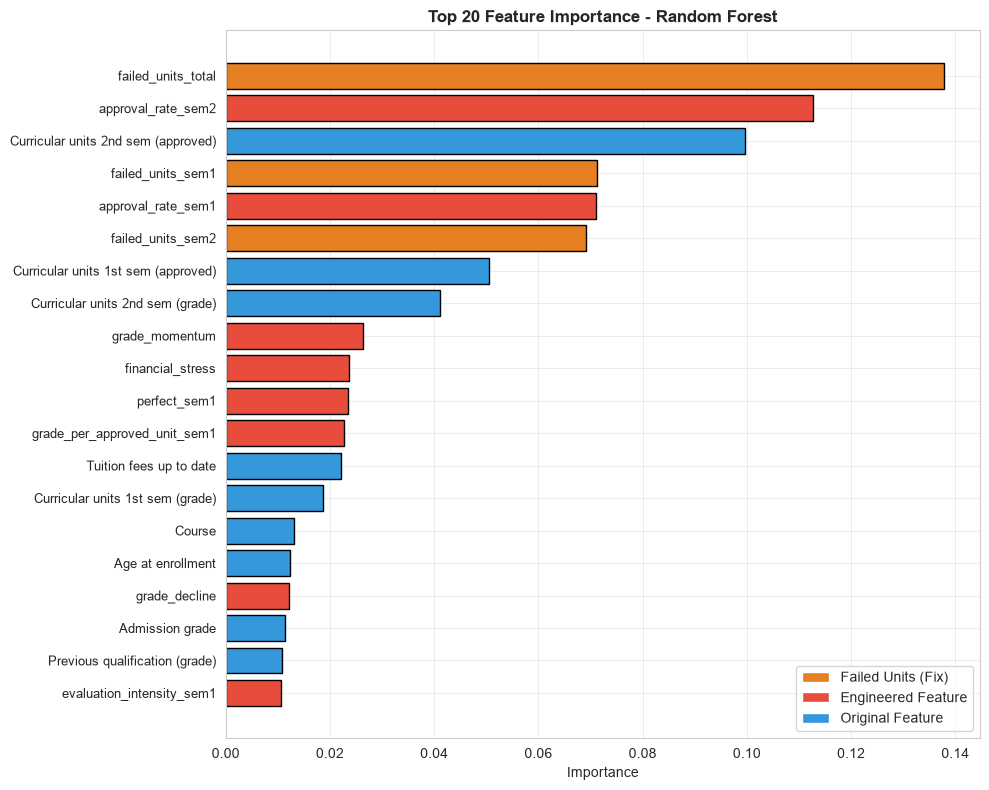

In [59]:
fig, ax = plt.subplots(figsize=(10.0, 8.0))
top_features = importance_df.head(20)
colors = []
for f in top_features['Feature']:
    if f in new_failed_features:
        colors.append('#e67e22')  # Orange for failed_units
    elif f in new_features:
        colors.append('#e74c3c')  # Red for engineered
    else:
        colors.append('#3498db')  # Blue for original

ax.barh(range(len(top_features)), top_features['Importance'].values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f[:45] + '...' if len(f) > 48 else f for f in top_features['Feature']], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importance - Random Forest', fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e67e22', label='Failed Units (Fix)'),
    Patch(facecolor='#e74c3c', label='Engineered Feature'),
    Patch(facecolor='#3498db', label='Original Feature')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.12 Save Processed Datasets

In [60]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)

# Save full model datasets
print("Saving full model datasets...")
X_train.to_csv('../data/processed/X_train_full.csv', index=False)
y_train.to_csv('../data/processed/y_train_full.csv', index=False)
X_val.to_csv('../data/processed/X_val_full.csv', index=False)
y_val.to_csv('../data/processed/y_val_full.csv', index=False)
X_test.to_csv('../data/processed/X_test_full.csv', index=False)
y_test.to_csv('../data/processed/y_test_full.csv', index=False)
print("    - X_train_full.csv, y_train_full.csv")
print("    - X_val_full.csv, y_val_full.csv")
print("    - X_test_full.csv, y_test_full.csv")
print()

# Save early intervention datasets
print("Saving early intervention datasets...")
X_early_train.to_csv('../data/processed/X_train_early.csv', index=False)
y_early_train.to_csv('../data/processed/y_train_early.csv', index=False)
X_early_test.to_csv('../data/processed/X_test_early.csv', index=False)
y_early_test.to_csv('../data/processed/y_test_early.csv', index=False)
print("    - X_train_early.csv, y_train_early.csv")
print("    - X_test_early.csv, y_test_early.csv")
print()

# Save preprocessor
print("Saving preprocessing pipeline...")
X_train_for_prep = df[all_feature_cols].loc[X_train.index]
preprocessor_linear.fit(X_train_for_prep)
joblib.dump(preprocessor_linear, '../models/preprocessor_linear.pkl')
print("    - preprocessor_linear.pkl")
print()

# Save feature metadata
print("Saving feature metadata...")
feature_metadata = {
    'feature_cols': tree_feature_cols,
    'early_features': early_features,
    'new_features': new_features,
    'failed_units_features': new_failed_features,
    'binary_features': binary_features,
    'ordinal_features': ordinal_features,
    'nominal_features': nominal_features,
    'continuous_features': continuous_features,
    'label_encoders': {k: list(v.classes_) for k, v in label_encoders.items()}
}
with open('../data/processed/feature_metadata.yaml', 'w') as f:
    yaml.dump(feature_metadata, f, default_flow_style=False)
print("    - feature_metadata.yaml")

# Save engineered dataframe
df.to_pickle('../data/processed/df_engineered.pkl')
print("    - df_engineered.pkl")
print()

print(f"All datasets saved!")

Saving full model datasets...
    - X_train_full.csv, y_train_full.csv
    - X_val_full.csv, y_val_full.csv
    - X_test_full.csv, y_test_full.csv

Saving early intervention datasets...
    - X_train_early.csv, y_train_early.csv
    - X_test_early.csv, y_test_early.csv

Saving preprocessing pipeline...
    - preprocessor_linear.pkl

Saving feature metadata...
    - feature_metadata.yaml
    - df_engineered.pkl

All datasets saved!


## 3.13 Summary

In [61]:
print(f"""
═══════════════════════════════════════════════════════════════
FEATURE ENGINEERING SUMMARY
═══════════════════════════════════════════════════════════════

DATASET OVERVIEW
  Total samples:            {len(df):,}
  Original features:        36
  Engineered features:      {len(new_features)} (11 original + {len(new_failed_features)} failed_units + 1 other)
  Final feature count:      {len(tree_feature_cols)}

NEW FAILED_UNITS FEATURES (Fix coefficient anomalies)
  - failed_units_sem1 (enrolled - approved, 1st sem)
  - failed_units_sem2 (enrolled - approved, 2nd sem)
  - failed_units_total (sum of both)
  - grade_per_approved_unit_sem1 (efficiency metric)

MODEL DATASETS
  Full Model:         {X_train.shape[0]:,} train, {X_val.shape[0]:,} val, {X_test.shape[0]:,} test
  Early Intervention: {X_early_train.shape[0]:,} train, {X_early_test.shape[0]:,} test
═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
FEATURE ENGINEERING SUMMARY
═══════════════════════════════════════════════════════════════

DATASET OVERVIEW
  Total samples:            3,630
  Original features:        36
  Engineered features:      15 (11 original + 3 failed_units + 1 other)
  Final feature count:      51

NEW FAILED_UNITS FEATURES (Fix coefficient anomalies)
  - failed_units_sem1 (enrolled - approved, 1st sem)
  - failed_units_sem2 (enrolled - approved, 2nd sem)
  - failed_units_total (sum of both)
  - grade_per_approved_unit_sem1 (efficiency metric)

MODEL DATASETS
  Full Model:         2,178 train, 726 val, 726 test
  Early Intervention: 2,904 train, 726 test
═══════════════════════════════════════════════════════════════



In [62]:
# Final data quality check
issues = []
if X_train.isnull().any().any():
    issues.append(f"NaN in training: {X_train.columns[X_train.isnull().any()].tolist()}")
if y_train.isnull().any():
    issues.append("NaN in training target")
if np.isinf(X_train.select_dtypes(include=['float64']).values).any():
    issues.append("Infinite values in training")

if issues:
    print("!  Issues found:")
    for issue in issues:
        print(f"    - {issue}")
else:
    print("+ All checks passed! Data ready for modeling.")
print()

print(f"Training shape: {X_train.shape}")
print(f"Feature dtypes:\n{X_train.dtypes.value_counts()}")

+ All checks passed! Data ready for modeling.

Training shape: (2178, 51)
Feature dtypes:
float64    30
int64      21
Name: count, dtype: int64
